In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
import torch
import pandas as pd
import scanpy as sc
import numpy as np
import scipy
import warnings
from sigma.toolkit import set_seed
from sigma.toolkit import clustering
from sigma.data.spatial_graph import build_spatial_network
from sigma.data.preparation import add_local_rna_similarity_edges, build_batch_triplet_inputs, prepare_harmony_rna_protein_features, stitch_slice_graphs
from matplotlib import pyplot as plt
set_seed(2024)
warnings.filterwarnings('ignore')
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# read data
file_folds = ['../SIGMA_data/Human_tonsil/slice1/','../SIGMA_data/Human_tonsil/slice2/','../SIGMA_data/Human_tonsil/slice3/']  #please replace 'file_fold' with the download path
name = ["slice1", "slice2", "slice3"]
rna_adatas = {}
adt_adatas = {}
# Three slices, each with two feature sets
for file_fold, name in zip(file_folds, name):
    adata_omics1 = sc.read_h5ad(file_fold + 'adata_rna.h5ad')
    adata_omics2 = sc.read_h5ad(file_fold + 'adata_adt.h5ad')
    adata_omics1.var_names_make_unique()
    adata_omics2.var_names_make_unique()
    build_spatial_network(adata_omics1, model="KNN", n_neighbors=6)
    build_spatial_network(adata_omics2, model="KNN", n_neighbors=6)
    add_local_rna_similarity_edges(
        adata_list=[adata_omics1, adata_omics2],
        rna_adata=adata_omics1,
        ratio=0.005,
        min_cells=10,
        n_top_genes=5000,
        n_comps=50,
    )
    rna_adatas[name] = adata_omics1.copy()
    adt_adatas[name] = adata_omics2.copy()
    # Store it in a dictionary
adata_RNA=sc.concat(rna_adatas, label="batch",index_unique="_")
adata_ADT=sc.concat(adt_adatas, label="batch",index_unique="_")
# Concatenate them together
stitch_slice_graphs(rna_adatas, adt_adatas, adata_RNA, adata_ADT)
adata_RNA.obs['anno']=adata_RNA.obs['final_annot'].map({"tonsillar parenchyma":"tonsillar parenchyma"  ,
"lymphoid follicle" :"lymphoid follicle"  ,
"connective & epithelial tissue" :"connective & epithelial tissue"  ,
"connective and epithelial tissue" :"connective & epithelial tissue" ,
"germinal center":"germinal center" ,
"germinal Center":"germinal center" })


/opt/miniconda/envs/smart_new/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The graph contains 25956 edges, 4326 cells.
6.0000 neighbors per cell on average.
The graph contains 25956 edges, 4326 cells.
6.0000 neighbors per cell on average.
Original edges: 25956, planned new edges: 129
Actual undirected new edges: 129
Actual directed new edges: 258
  Final modality edge count: 26214
  Final modality edge count: 26214
The graph contains 27114 edges, 4519 cells.
6.0000 neighbors per cell on average.
The graph contains 27114 edges, 4519 cells.
6.0000 neighbors per cell on average.
Original edges: 27114, planned new edges: 135
Actual undirected new edges: 135
Actual directed new edges: 270
  Final modality edge count: 27384
  Final modality edge count: 27384
The graph contains 27126 edges, 4521 cells.
6.0000 neighbors per cell on average.
The graph contains 27126 edges, 4521 cells.
6.0000 neighbors per cell on average.
Original edges: 27126, planned new edges: 135
Actual undirected new edges: 135
Actual directed new edges: 270
  Final modality edge count: 27396
  F

In [2]:
adata_RNA, adata_ADT, adata_list = prepare_harmony_rna_protein_features(
    adata_rna=adata_RNA,
    adata_protein=adata_ADT,
    batch_key="batch",
    min_cells=10,
    n_top_genes=5000,
    rna_n_comps=50,
    protein_n_comps=30,
)
x, edges, triplet_samples_list = build_batch_triplet_inputs(
    adata_list=adata_list,
    device=device,
    feature_key="X_pca_harmony",
    batch_key="batch",
    far_frac=0.8,
    top_k=1,
)


Use GPU mode.
	Initialization is completed.
	Completed 1 / 20 iteration(s).
	Completed 2 / 20 iteration(s).
	Completed 3 / 20 iteration(s).
	Completed 4 / 20 iteration(s).
	Completed 5 / 20 iteration(s).
	Completed 6 / 20 iteration(s).
Reach convergence after 6 iteration(s).
Use GPU mode.
	Initialization is completed.
	Completed 1 / 20 iteration(s).
	Completed 2 / 20 iteration(s).
	Completed 3 / 20 iteration(s).
	Completed 4 / 20 iteration(s).
	Completed 5 / 20 iteration(s).
	Completed 6 / 20 iteration(s).
	Completed 7 / 20 iteration(s).
	Completed 8 / 20 iteration(s).
	Completed 9 / 20 iteration(s).
	Completed 10 / 20 iteration(s).
	Completed 11 / 20 iteration(s).
	Completed 12 / 20 iteration(s).
	Completed 13 / 20 iteration(s).
	Completed 14 / 20 iteration(s).
	Completed 15 / 20 iteration(s).
Reach convergence after 15 iteration(s).
Batch slice1 vs slice2: 1112 MNN (top-1) triplets
Batch slice1 vs slice3: 1054 MNN (top-1) triplets
Batch slice2 vs slice3: 1035 MNN (top-1) triplets
Bat

In [3]:
from sigma.training import fit_sigma_embedding
model = fit_sigma_embedding(
    adata=adata_RNA,
    features=x,
    edges=edges,
    triplet_samples_list=triplet_samples_list,
    weights=[1, 1, 1, 1],
    emb_dim=64,
    n_epochs=600,
    lr=5e-4,
    weight_decay=1e-6,
    device=device,
    window_size=10,
    slope=0.0001,
    contrastive_alpha=0.16,
    contrastive_temperature=0.5,
    alpha=0.05,
    seed=2024,
    forward_kwargs={"alpha": 0.05},
)
from sigma.reporting import cluster_and_score_ari
tool = 'mclust'  # mclust, leiden, and louvain
ari = cluster_and_score_ari(
    adata_RNA,
    label_key='anno',
    cluster_key='SIGMA',
    embedding_key='SIGMA',
    n_clusters=6,
    method=tool,
    use_pca=True,
    drop_missing_labels=True,
)

 60%|█████▉    | 359/600 [00:38<00:25,  9.34it/s]


Early stopping at epoch 360: tri_slope=-0.000044, rec_slope=-0.000082


R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.2
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%
0.30846731264496785


In [4]:
from sigma.reporting import run_cluster_range_benchmark
result_df, mean_result, summary_result, summary_df = run_cluster_range_benchmark(
    adata_RNA,
    method_name="SIGMA",
    embedding_key="SIGMA",
    batch_key="batch",
    label_key="anno",
    cluster_range=[4, 5, 6, 7, 8],
    clustering_method="mclust",
    use_pca=True,
)



===== Clustering: 4 =====
fitting ...
  |======================================================================| 100%
ARI: 0.405380
NMI: 0.356788
AMI: 0.356584
Homo: 0.353831
V-Measure: 0.356788
FMI: 0.658816
MI: 0.380759

===== Clustering: 5 =====
fitting ...
  |======================================================================| 100%
ARI: 0.329358
NMI: 0.314953
AMI: 0.314699
Homo: 0.356387
V-Measure: 0.314953
FMI: 0.576402
MI: 0.383509

===== Clustering: 6 =====
fitting ...
  |======================================================================| 100%
ARI: 0.308467
NMI: 0.312012
AMI: 0.311709
Homo: 0.370827
V-Measure: 0.312012
FMI: 0.554873
MI: 0.399048

===== Clustering: 7 =====
fitting ...
  |======================================================================| 100%
ARI: 0.191652
NMI: 0.274842
AMI: 0.274500
Homo: 0.367221
V-Measure: 0.274842
FMI: 0.431912
MI: 0.395168

===== Clustering: 8 =====
fitting ...
  |==================================================================

/opt/miniconda/envs/smart_new/lib/python3.9/site-packages/scib/knn_graph/knn_graph.o: /usr/lib/x86_64-linux-gnu/libc.so.6: version `GLIBC_2.38' not found (required by /opt/miniconda/envs/smart_new/lib/python3.9/site-packages/scib/knn_graph/knn_graph.o)
/opt/miniconda/envs/smart_new/lib/python3.9/site-packages/scib/knn_graph/knn_graph.o: /usr/lib/x86_64-linux-gnu/libstdc++.so.6: version `GLIBCXX_3.4.32' not found (required by /opt/miniconda/envs/smart_new/lib/python3.9/site-packages/scib/knn_graph/knn_graph.o)



scIB batch metrics failed; using fallback implementation. Reason: [Errno 2] No such file or directory: '/tmp/lisi_awfiwx93/graph_lisi_indices_0.txt'

Batch Metrics
Batch metric source: fallback
iLISI: 0.941208
kBET: 0.795024

Final Summary Metrics
ARI: 0.276778
NMI: 0.305779
AMI: 0.305482
Homo: 0.366524
V-Measure: 0.305779
FMI: 0.520391
MI: 0.394417
iLISI: 0.941208
kBET: 0.795024
Bio conservation: 0.353593
Batch correction: 0.868116
Total: 0.467931

Summary Table
            ARI       FMI       NMI       AMI        MI  V-Measure      Homo  \
SIGMA  0.276778  0.520391  0.305779  0.305482  0.394417   0.305779  0.366524   

          iLISI      kBET  Bio conservation  Batch correction     Total  
SIGMA  0.941208  0.795024          0.353593          0.868116  0.467931  


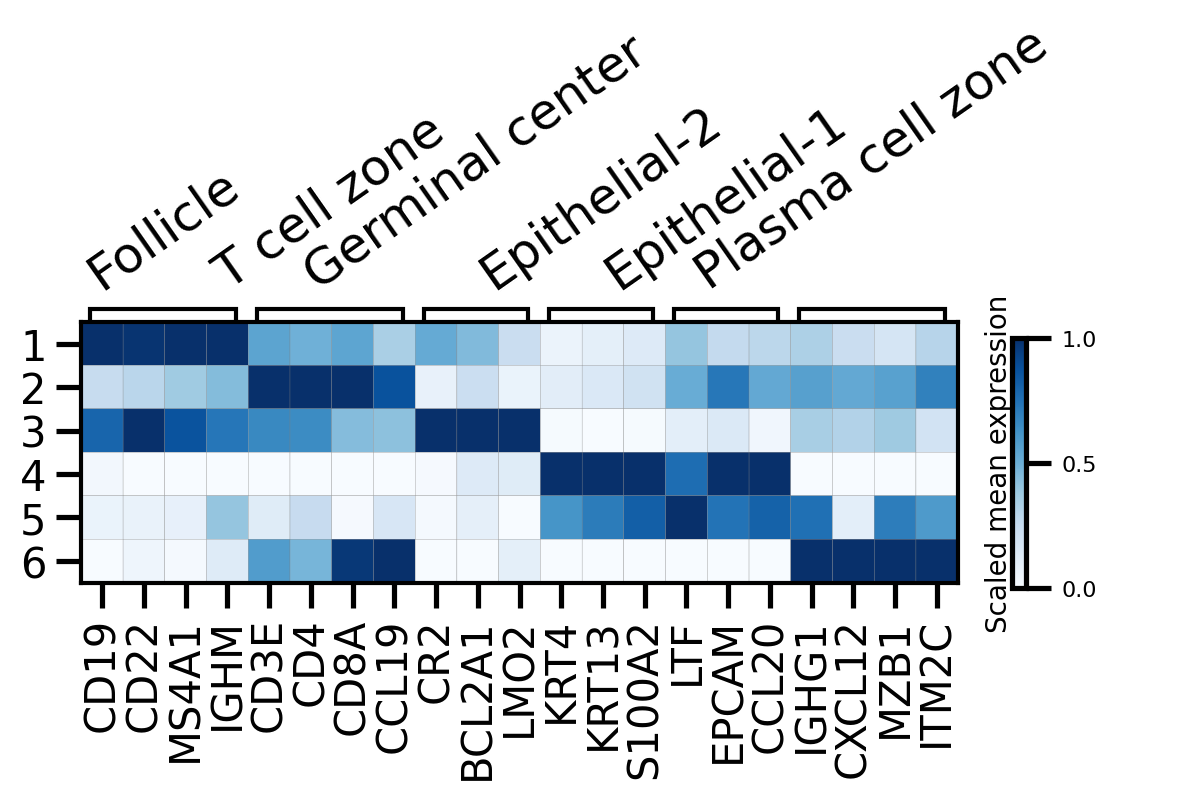

In [5]:
import pandas as pd
import scanpy as sc
adata_RNA.obs["SIGMA_6_new"] = adata_RNA.obs["SIGMA_6"].astype(str)
SIGMA_markers = {
    "Follicle": ["CD19", "CD22", "MS4A1", "IGHM"],
    "T cell zone": ["CD3E", "CD4", "CD8A", "CCL19"],
    "Germinal center": ["CR2", "BCL2A1", "LMO2"],
    "Epithelial-2": ["KRT4", "KRT13", "S100A2"],
    "Epithelial-1": ["LTF", "EPCAM", "CCL20"],
    "Plasma cell zone": ["IGHG1", "CXCL12", "MZB1", "ITM2C"],
}
import matplotlib as mpl
import matplotlib.pyplot as plt
import scanpy as sc
fig, ax = plt.subplots(1, 1, figsize=(7, 2.5), dpi=200)
mp = sc.pl.matrixplot(
    adata_RNA,
    SIGMA_markers,
    groupby="SIGMA_6_new",
    cmap="Blues",
    standard_scale="var",
    ax=ax,
    show=False,
    var_group_rotation=35,   # controls the tilt of the top Follicle / T cell zone labels
)
# ❗remove scanpy default colorbar
mp["color_legend_ax"].remove()
# =========================
# add your own colorbar
# =========================
cmap = mpl.colormaps["Blues"]
norm = mpl.colors.Normalize(vmin=0, vmax=1)
cbar_ax = fig.add_axes([0.79, 0.1, 0.01, 0.5])
cbar = fig.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=cbar_ax,
    orientation="vertical",
    ticks=[0, 0.5, 1],
)
# ✔ you can now fully control it
cbar.ax.tick_params(labelsize=8)
cbar.set_label(
    "Scaled mean expression",
    rotation=90,
    size=10,
    labelpad=-40
)
plt.show()
sigma_cluster_names = {
    "1": "Follicle",
    "2": "T cell zone",
    "3": "Germinal center",
    "4": "Epithelial-2",
    "5": "Epithelial-1",
    "6": "Plasma cell zone",
}
#


In [6]:
adata_ADT.obs = adata_ADT.obs.join(
    adata_RNA.obs[["SIGMA_6_new"]].astype(str),
    how="left"
)


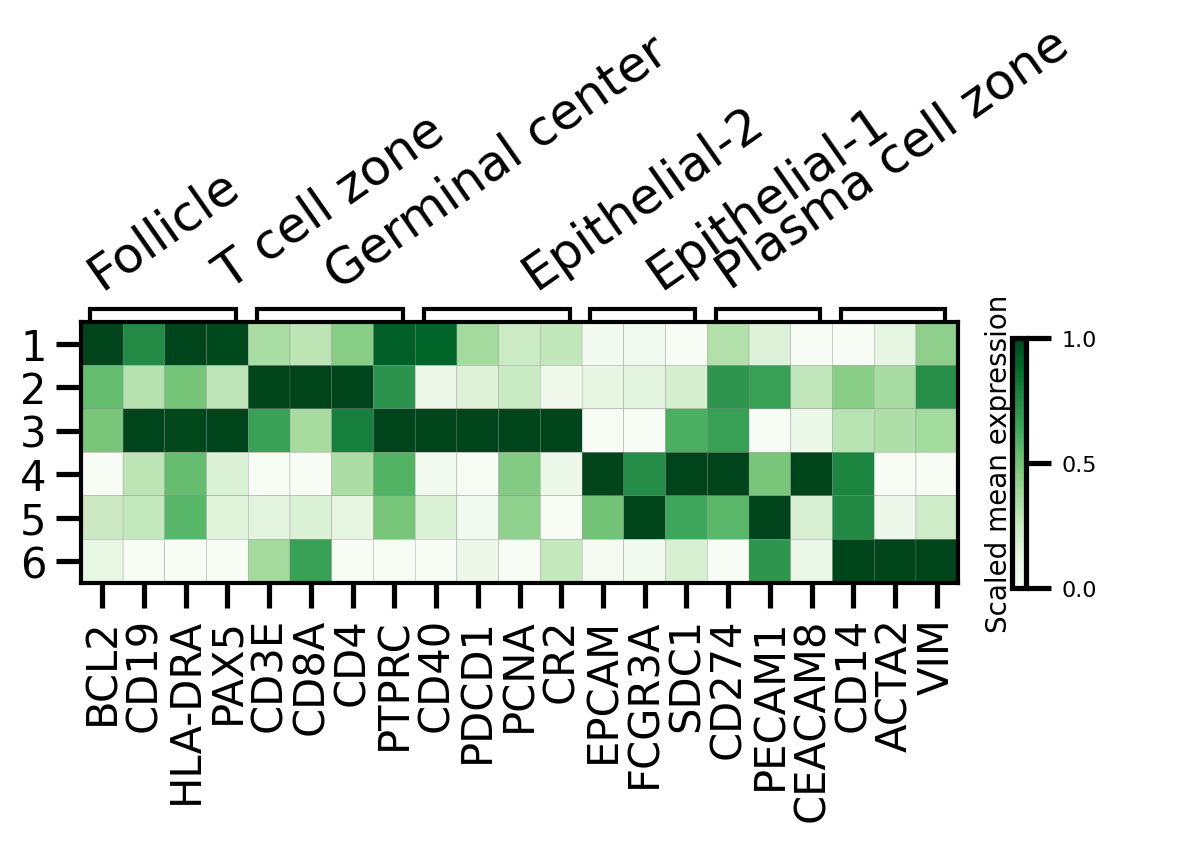

In [7]:
import pandas as pd
import scanpy as sc
import matplotlib as mpl
from matplotlib import pyplot as plt
# =========================
# 1. transfer RNA cluster labels to ADT (SAFE WAY)
# =========================
# =========================
# 2. ADT marker genes
# =========================
SIGMA_markers_adt = {
    "Follicle": ["BCL2", "CD19", "HLA-DRA", "PAX5"],
    "T cell zone": ["CD3E", "CD8A", "CD4", "PTPRC"],
    "Germinal center": ["CD40", "PDCD1", "PCNA", "CR2"],
    "Epithelial-2": ["EPCAM", "FCGR3A", "SDC1"],
    "Epithelial-1": ["CD274", "PECAM1", "CEACAM8"],
    "Plasma cell zone": ["CD14", "ACTA2", "VIM"],
}
# =========================
# 3. matrixplot (same style as RNA)
# =========================
fig, ax = plt.subplots(1, 1, figsize=(7, 2.5), dpi=200)
mp = sc.pl.matrixplot(
    adata_ADT,
    SIGMA_markers_adt,
    groupby="SIGMA_6_new",
    cmap="Greens",
    standard_scale="var",
    swap_axes=False,
    ax=ax,
    show=False,
    var_group_rotation=35,   # controls the tilt of the top Follicle / T cell zone labels
)
# remove default legend
mp["color_legend_ax"].remove()
# =========================
# 4. custom colorbar
# =========================
cmap = mpl.colormaps["Greens"]
norm = mpl.colors.Normalize(vmin=0, vmax=1)
cbar_ax = fig.add_axes([0.79, 0.1, 0.01, 0.5])
cbar = fig.colorbar(
    mpl.cm.ScalarMappable(norm=norm, cmap=cmap),
    cax=cbar_ax,
    orientation="vertical",
    ticks=[0, 0.5, 1],
)
cbar.ax.tick_params(labelsize=8)
cbar.set_label("Scaled mean expression", rotation=90, size=10, labelpad=-40)
# =========================
# 5. show + save
# =========================
plt.show()
fig.savefig(
    "adt_matrixplot.svg",
    format="svg",
    bbox_inches="tight",
    transparent=True
)


/tmp/ipykernel_360806/2832296843.py:54: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="center")


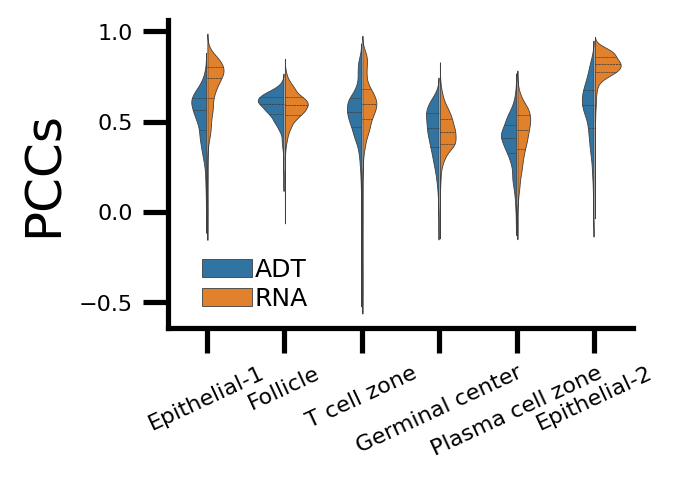

In [12]:
# PCC violin plot: compare SIGMA embedding with RNA/ADT Harmony embeddings
from sklearn.metrics.pairwise import pairwise_distances
from scipy.stats import pearsonr
import seaborn as sns
# SIGMA embedding distance
sigma_dis = pairwise_distances(adata_RNA.obsm["SIGMA"])
# Modality-specific Harmony embedding distances
rna_dis = pairwise_distances(adata_RNA.obsm["X_pca_harmony"])
adt_dis = pairwise_distances(adata_ADT.obsm["X_pca_harmony"])
# Use the current SIGMA clustering result as the cluster label.
# The mapping follows Human_tonsil_result_figure.ipynb; unmapped labels fall back to the raw cluster id.
cluster_key = "SIGMA"
sigma_cluster_names = {
    "1": "Follicle",
    "2": "T cell zone",
    "3": "Germinal center",
    "4": "Epithelial-2",
    "5": "Epithelial-1",
    "6": "Plasma cell zone",
}
cluster_order = [
    "Epithelial-1",
    "Follicle",
    "T cell zone",
    "Germinal center",
    "Plasma cell zone",
    "Epithelial-2",
]
cluster_ids = adata_RNA.obs[cluster_key].astype(str)
cluster_labels = cluster_ids.map(sigma_cluster_names).fillna(cluster_ids)
df2 = pd.DataFrame(columns=["cluster", "modality", "pearsonr"])
for i, cluster in enumerate(cluster_labels.values):
    corr, _ = pearsonr(sigma_dis[i], adt_dis[i])
    df2.loc[len(df2)] = [cluster, "ADT", corr]
    corr, _ = pearsonr(sigma_dis[i], rna_dis[i])
    df2.loc[len(df2)] = [cluster, "RNA", corr]
fig, ax = plt.subplots(figsize=(3, 2), dpi=200)
ax.tick_params(labelsize=8)
sns.violinplot(
    data=df2,
    x="cluster",
    y="pearsonr",
    hue="modality",
    split=True,
    gap=.05,
    inner="quart",
    linewidth=0.3,
    width=0.7,
    ax=ax,
    order=cluster_order,
)
ax.set_ylabel("PCCs")
ax.set_xlabel("")
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="center")
ax.legend(
    bbox_to_anchor=(0.35, 0.3),
    frameon=False,
    ncol=1,
    labelspacing=0.2,
    handletextpad=0.1,
    fontsize=9,
)
sns.despine()
fig.savefig("PCCs.svg", format="svg", bbox_inches="tight", transparent=True)
plt.show()


In [13]:
# Save PCC metrics to Excel
summary_df = (
    df2.groupby(["cluster", "modality"])["pearsonr"]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .reset_index()
)
with pd.ExcelWriter("PCCs_metrics_mul.xlsx") as writer:
    df2.to_excel(writer, sheet_name="per_cell_PCC", index=False)
    summary_df.to_excel(writer, sheet_name="summary", index=False)


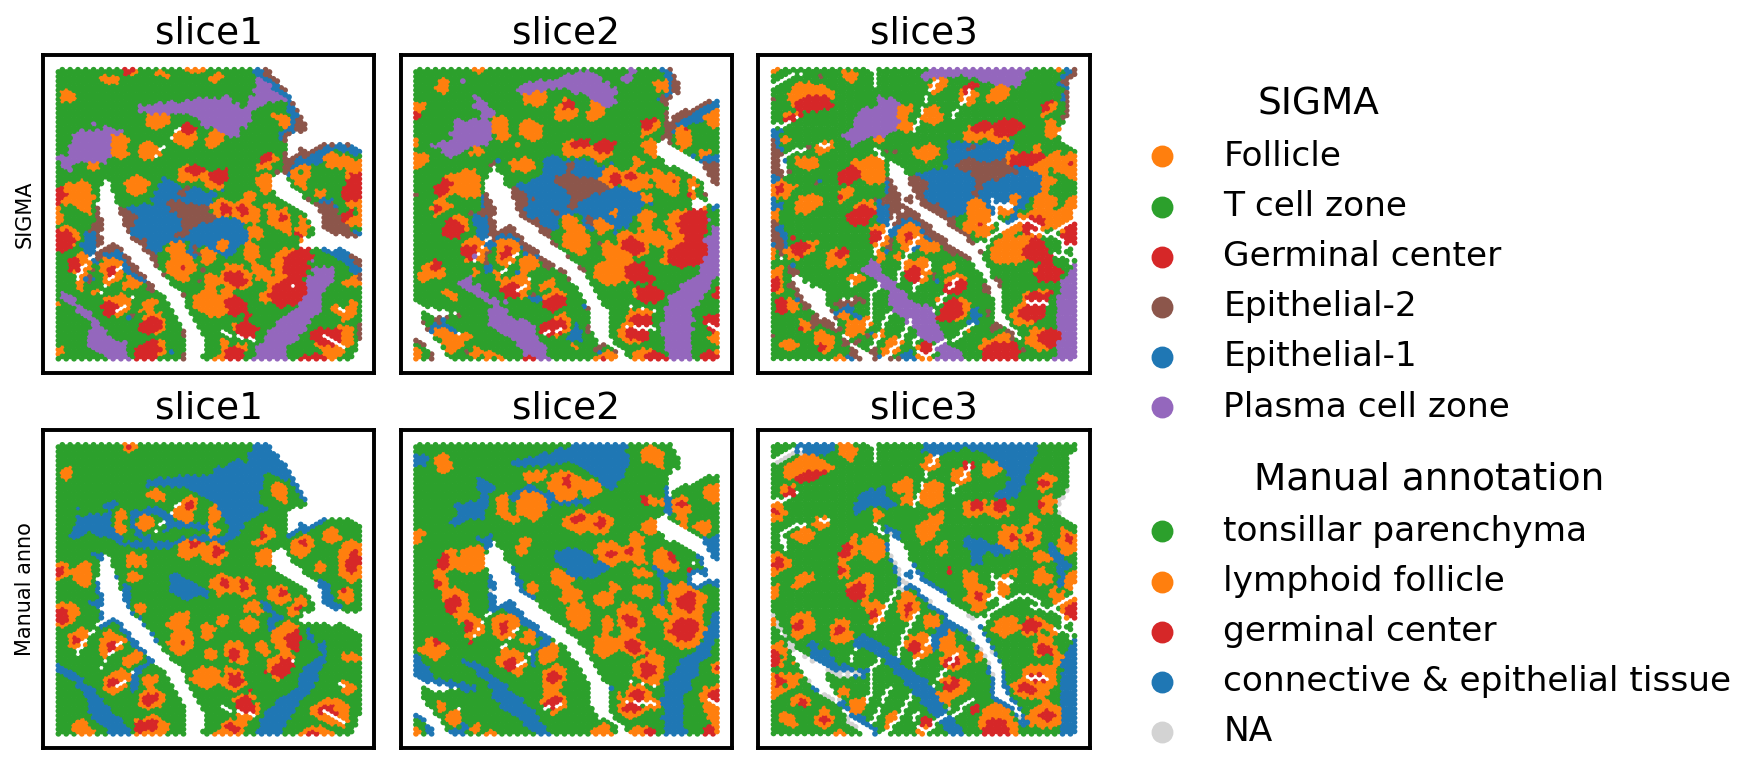

In [14]:
# ===== Plot SIGMA/SIGMA domains and manual annotation together across three tonsil slices =====
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
batch_key = "batch"
batch_order = ["slice1", "slice2", "slice3"]
sigma_cluster_names = {
    "1": "Follicle",
    "2": "T cell zone",
    "3": "Germinal center",
    "4": "Epithelial-2",
    "5": "Epithelial-1",
    "6": "Plasma cell zone",
}
sigma_order = [
    "Follicle",
    "T cell zone",
    "Germinal center",
    "Epithelial-2",
    "Epithelial-1",
    "Plasma cell zone",
]
sigma_palette = {
    "Follicle": "#ff7f0e",
    "T cell zone": "#2ca02c",
    "Germinal center": "#d62728",
    "Epithelial-2": "#8c564b",
    "Epithelial-1": "#1f77b4",
    "Plasma cell zone": "#9467bd",
}
adata_RNA.obs["SIGMA_name"] = pd.Categorical(
    adata_RNA.obs["SIGMA"].astype(str).map(sigma_cluster_names),
    categories=sigma_order,
    ordered=True,
)
anno_key = "anno"
if anno_key not in adata_RNA.obs:
    raise KeyError(f"adata_RNA.obs['{anno_key}'] is missing. Run the annotation mapping cell first.")
anno_order = [
    "tonsillar parenchyma",
    "lymphoid follicle",
    "germinal center",
    "connective & epithelial tissue",
]
anno_palette = {
    "tonsillar parenchyma": "#2ca02c",
    "lymphoid follicle": "#ff7f0e",
    "germinal center": "#d62728",
    "connective & epithelial tissue": "#1f77b4",
}
observed_annos = [x for x in anno_order if x in set(adata_RNA.obs[anno_key].dropna().astype(str))]
extra_annos = [
    x for x in pd.Index(adata_RNA.obs[anno_key].dropna().astype(str)).drop_duplicates().tolist()
    if x not in observed_annos
]
anno_categories = observed_annos + extra_annos
adata_RNA.obs[anno_key] = pd.Categorical(
    adata_RNA.obs[anno_key].astype(str),
    categories=anno_categories,
    ordered=True,
)
fallback_colors = ["#9467bd", "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf"]
for i, anno_name in enumerate(extra_annos):
    anno_palette.setdefault(anno_name, fallback_colors[i % len(fallback_colors)])
adata_RNA.uns.pop("SIGMA_name_colors", None)
adata_RNA.uns.pop(f"{anno_key}_colors", None)
fig, ax_list = plt.subplots(2, 3, figsize=(9, 6), dpi=150)
plt.subplots_adjust(hspace=0.18, wspace=0.08)
for col, batch in enumerate(batch_order):
    adata_slice = adata_RNA[adata_RNA.obs[batch_key] == batch].copy()
    sc.pl.embedding(
        adata_slice,
        basis="spatial",
        color="SIGMA_name",
        ax=ax_list[0, col],
        title=batch,
        s=30,
        palette=sigma_palette,
        show=False,
    )
    sc.pl.embedding(
        adata_slice,
        basis="spatial",
        color=anno_key,
        ax=ax_list[1, col],
        title=batch,
        s=30,
        palette=anno_palette,
        show=False,
    )
    for row in range(2):
        ax_list[row, col].set_xlabel("")
        ax_list[row, col].set_ylabel("")
    if col < len(batch_order) - 1:
        for row in range(2):
            legend = ax_list[row, col].get_legend()
            if legend is not None:
                legend.remove()
ax_list[0, 0].set_ylabel("SIGMA", fontsize=10)
ax_list[1, 0].set_ylabel("Manual anno", fontsize=10)
sigma_legend = ax_list[0, 2].get_legend()
if sigma_legend is not None:
    sigma_legend.set_title("SIGMA")
    sigma_legend.set_bbox_to_anchor((1.02, 1.0))
    sigma_legend._loc = 2
anno_legend = ax_list[1, 2].get_legend()
if anno_legend is not None:
    anno_legend.set_title("Manual annotation")
    anno_legend.set_bbox_to_anchor((1.02, 1.0))
    anno_legend._loc = 2
fig.savefig("Human_tonsil_SIGMA_and_anno_three_slices.jpg", format="jpg", bbox_inches="tight", transparent=True)
fig.savefig("Human_tonsil_SIGMA_and_anno_three_slices.png", format="png", bbox_inches="tight", transparent=True)
plt.show()


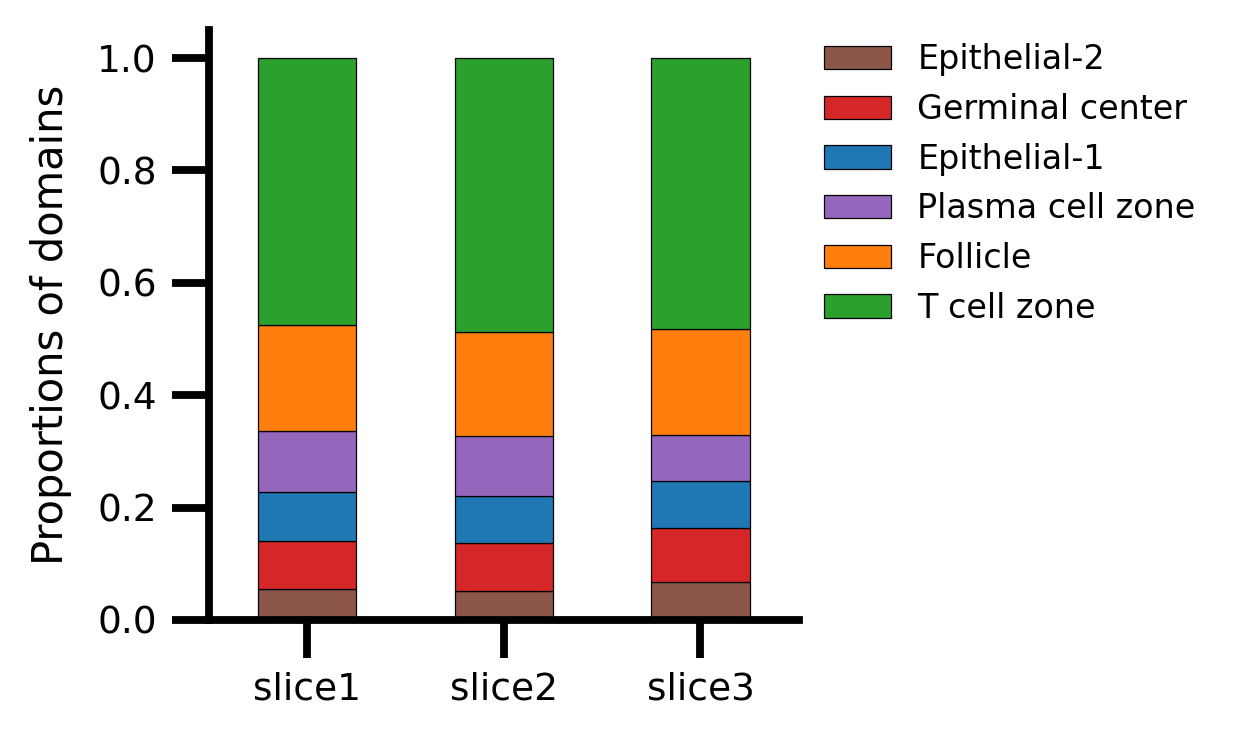

In [16]:
fig, ax = plt.subplots(figsize=(4.5, 2.8), dpi=300)

ax.tick_params(labelsize=9)

plot_df.plot(
    kind="bar",
    stacked=True,
    ax=ax,
    edgecolor="black",
    linewidth=0.3,
    color=[colordict2[x] for x in plot_order],
)

sns.despine()

# ===== 1. y轴 label优化 =====
ax.set_ylabel("Proportions of domains", fontsize=10, labelpad=6)

# ===== 2. x轴 =====
ax.set_xlabel("")
ax.set_xticklabels(batch_order, rotation=0, ha="center", fontsize=9)

# ===== 3. legend 放外面（关键）=====
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False,
    ncol=1,
    fontsize=8,
    borderaxespad=0
)

# ===== 4. 防止裁切（关键）=====
plt.tight_layout()

# 如果 svg 还是裁切，再加这个
fig.savefig(
    "Proportions.svg",
    format="svg",
    bbox_inches="tight",
    pad_inches=0.2,
    transparent=True
)

plt.show()